### Goal, look at if conserved indices in the MSA predict r_A, or if the same can be said of sector indices. 

Collect matrices which are (1) SCA sector 3/5 positions in MSA for each isolate sequence, (2) conserved positions in MSA for each isolate sequence, (3) a vector of r_A's for each sequence. 

Then, do PCA to get PCA coordinates for each of the three matrices. Run a LASSO to try to predict r_As from PCA coordinates. 

In [95]:
# load in the data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

conservation = np.load('../data/isolate_seqs/isolates_sca_results/conservation.npy')
msa = np.load('../data/isolate_seqs/isolates_sca_results/msa.npy')
seq_ids = np.load('../data/isolate_seqs/isolates_sca_results/retained_sequence_ids.npy')
sec3_pos = np.load('../data/isolate_seqs/isolates_sca_results/sector_3_msapos.npy')
sec5_pos = np.load('../data/isolate_seqs/isolates_sca_results/sector_5_msapos.npy')
sec3_scores = np.load('../data/isolate_seqs/isolates_sca_results/sector_3_scores.npy')
sec5_scores = np.load('../data/isolate_seqs/isolates_sca_results/sector_5_scores.npy')

strain_list = pd.read_csv('../data/isolate_seqs/strain_list.csv')
id_list_tot = strain_list['Strain'].values

indices = [] #indicies in the MSA corresponding to isolate strains
for i, seq in enumerate(seq_ids):
    if seq in id_list_tot:
        indices.append(i)
        
id_list = seq_ids[indices]

msa_isolates = msa[indices]

N = len(msa[0]) #length of msa elements

conserved_indices = np.where(conservation > np.mean(conservation) + 0*np.std(conservation))[0]
sec3_indices = np.where(sec3_scores > np.mean(sec3_scores) + 0*np.std(sec3_scores))[0]
sec5_indices = np.where(sec5_scores > np.mean(sec5_scores) + 0*np.std(sec5_scores))[0]
msa_conserved = msa_isolates[:, conserved_indices]

print('len(sec3_pos)', len(sec3_pos), 'len(sec3_scores)', len(sec3_scores))

sec3_indices = sec3_pos[sec3_indices]
sec5_indices = sec5_pos[sec5_indices]


msa_sec3 = msa_isolates[:, sec3_pos]
msa_sec5 = msa_isolates[:, sec5_pos]

# print(len(sec3_indices))
# print(len(sec5_indices))
# print(msa_sec5.shape)
print('sec 5 pos', sec5_pos)

import random
random_indices = random.sample(range(1, len(msa[0])), 50)
msa_random = msa_isolates[:, random_indices]
# print(len(conserved_indices))

# print(seq_ids[indices])
# print(id_list_tot)
# print("Missing ids:", set(id_list_tot) -  set(seq_ids[indices]))

len(sec3_pos) 90 len(sec3_scores) 90
sec 5 pos [1066 1109 1021 1110 1037 1085 1118 1101 1094 1119 1112 1099  998 1042
 1103 1075 1082 1050 1100 1001 1056 1084 1034 1080 1015 1115 1060 1045
 1088 1093 1010 1039 1035 1108  995 1026 1125 1027 1053 1016  997  993
 1086 1013 1054 1051 1044 1106 1004 1000 1006  994 1011  959 1067  967
  958 1102  948  966 1077  952  951  945  974 1074  949 1041]


In [156]:
#orf_list = pd.read_csv('../out/aaseqs/K00370/long_complete_orf_ids.txt', header = None).values
orf_list = pd.read_csv('../out/aaseqs/K00370/proteo_orf_ids.txt', header = None).values
orf_indices = []
orf_list_ordered = []

for i, seq in enumerate(seq_ids):
    if seq in orf_list:
        orf_list_ordered.append(seq)
        orf_indices.append(i)

print(orf_indices)
print(len(orf_indices))

msa_proteo = msa[orf_indices]


[3081, 3351, 3391, 4049, 4060, 4085, 4104, 4108, 4110, 4241, 4353, 4435, 4439, 4477, 4941, 5070, 5076, 8605]
18


In [96]:
print(conserved_indices)
print(sec3_pos)
print(sec5_pos)

[   2   12   14   15   18   19   21   22   24   25   26   28   29   30
   31   32   33   34   35   36   37   38   39   40   41   42   44   45
   46   47   49   50   51   52   53   54   56   59   60   61   68   70
   71   72   73   74   75   76   77   78   79   80   81   82   83   84
   86   87   88   90   92   93   94   95   97  100  104  105  112  113
  114  116  117  120  123  130  134  135  137  138  139  141  144  146
  149  152  153  157  158  162  163  164  165  166  169  170  171  172
  173  174  175  176  177  178  180  181  182  184  186  187  190  192
  193  197  198  199  200  201  202  203  204  205  206  208  209  210
  211  213  214  215  216  217  218  219  221  222  224  225  226  227
  230  234  235  237  239  241  242  243  244  245  247  248  251  253
  254  256  258  260  264  265  266  271  272  273  274  276  282  284
  286  288  289  290  291  293  294  295  296  298  299  300  306  307
  310  314  315  316  318  319  320  321  323  334  335  336  347  348
  353 

In [97]:
print(sec3_pos)
print(sec5_pos)

conserved_indices_np = np.array(conserved_indices)
sec3_pos_np = np.array(sec3_pos)
sec5_pos_np = np.array(sec5_pos)

mask3 = np.isin(conserved_indices_np, sec3_pos_np)
mask5 = np.isin(conserved_indices_np, sec5_pos_np)
sec3_conserved = np.where(mask3)[0]
sec5_conserved = np.where(mask5)[0]
sector_conserved = np.concatenate([sec3_conserved, sec5_conserved])
print(conserved_indices[sector_conserved])
print(sector_conserved)
#sector_conserved are the insdices in the conserved msa which are also in a sector

[ 42  83  32  36  40  53  75  22  18  60  86  56  35  84  21  73  72  68
  19  25  37  61  71  77  29  46  54  59  31  49  38  33  74 117  90  47
  94  12  78  97  82  34  28  41  87 100  26 116 134  93  24 113 135  52
 144 137 141 138 114  39 130 165 166 170 163 174 158 173  58 169 164 175
 107 153 123 146 177 160 162 121 101 126 186 184 119 145  55 106  96 180]
[1066 1109 1021 1110 1037 1085 1118 1101 1094 1119 1112 1099  998 1042
 1103 1075 1082 1050 1100 1001 1056 1084 1034 1080 1015 1115 1060 1045
 1088 1093 1010 1039 1035 1108  995 1026 1125 1027 1053 1016  997  993
 1086 1013 1054 1051 1044 1106 1004 1000 1006  994 1011  959 1067  967
  958 1102  948  966 1077  952  951  945  974 1074  949 1041]
[  12   18   19   21   22   24   25   26   28   29   31   32   33   34
   35   36   37   38   39   40   41   42   46   47   49   52   53   54
   56   59   60   61   68   71   72   73   74   75   77   78   82   83
   84   86   87   90   93   94   97  100  113  114  116  117  123  130
  13

### Collect rate parameters for the ids

In [98]:

parameters = pd.read_csv('../data/isolate_seqs/consumer_resource_parameters_SDM.csv')
rates = parameters.set_index('Strain').reindex(id_list).iloc[:, 0].values
gammas = parameters.set_index('Strain').reindex(id_list).iloc[:, 1].values

### Perform PCA

In [99]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder
import numpy as np

import numpy as np

def hydrophobic_encoding(msa_matrix):
    """
    Replace amino acid numbers in MSA matrix with hydrophobicity values.
    
    Args:
        msa_matrix: numpy array with numbers representing amino acids
                   (using your DEFAULT_MAP: "ACDEFGHIKLMNPQRSTVWY" -> 0-19)
    
    Returns:
        numpy array with same shape as msa_matrix, but with hydrophobicity values
    """
    # Kyte-Doolittle hydrophobicity scale (most commonly used)
    # Mapping for "ACDEFGHIKLMNPQRSTVWY" in order
    hydrophobicity_scale = {
        0: 1.8,   # A - Alanine
        1: 2.5,   # C - Cysteine  
        2: -3.5,  # D - Aspartic Acid
        3: -3.5,  # E - Glutamic Acid
        4: 2.8,   # F - Phenylalanine
        5: -0.4,  # G - Glycine
        6: -3.2,  # H - Histidine
        7: 4.5,   # I - Isoleucine
        8: -3.9,  # K - Lysine
        9: 3.8,   # L - Leucine
        10: 1.9,  # M - Methionine
        11: -3.5, # N - Asparagine
        12: -1.6, # P - Proline
        13: -3.5, # Q - Glutamine
        14: -4.5, # R - Arginine
        15: -0.8, # S - Serine
        16: -0.7, # T - Threonine
        17: 4.2,  # V - Valine
        18: -0.9, # W - Tryptophan
        19: -1.3, # Y - Tyrosine
        20: 0.0   # Gap - neutral hydrophobicity
    }
    
    #create mapping
    vectorized_map = np.vectorize(lambda x: hydrophobicity_scale.get(x, 0.0))
    
    hydrophobicity_matrix = vectorized_map(msa_matrix)
    
    return hydrophobicity_matrix

def one_hot_encode_msa(msa_matrix):
    """
    Convert MSA matrix (n_sequences x n_positions) with values 0-20 
    """
    n_seqs, n_pos = msa_matrix.shape
    print(f"Original MSA shape: {msa_matrix.shape}")
    print(f"Unique values in data: {np.unique(msa_matrix)}")
    
    # Check if we have gaps (value 20) in this particular MSA
    has_gaps = 20 in msa_matrix
    if has_gaps:
        categories = [range(0, 21)]  # 0-20: 20 AAs + gaps
        n_categories = 21
    else:
        categories = [range(0, 20)]  # 0-19: 20 AAs only
        n_categories = 20
    
    # Reshape for one-hot encoding (flatten all positions)
    msa_flat = msa_matrix.reshape(-1, 1)
    
    # One-hot encode with appropriate categories
    encoder = OneHotEncoder(categories=categories, sparse_output=False)
    msa_onehot = encoder.fit_transform(msa_flat)
    
    # Reshape back to (n_sequences, n_positions * n_categories)
    msa_onehot = msa_onehot.reshape(n_seqs, -1)
    print(f"One-hot encoded shape: {msa_onehot.shape}")
    print(f"Total features: {n_pos} positions × {n_categories} categories = {msa_onehot.shape[1]} columns")
    
    return msa_onehot

def compute_pca_components(data, n_components=3):
    pca = PCA(n_components=n_components)
    pca_components = pca.fit_transform(data)
    explained_ratio = pca.explained_variance_ratio_
    return pca_components, explained_ratio




### Try a LASSO directly mapping onto r_A from the one hot encoding

In [111]:


def msa_regression(msa, values, test_size=0.2, random_state=42, plot = True):
    """
    Lasso regression for MSA one-hot encoded data (sets coefficients to zero)
    """
    #split data
    X_train, X_test, y_train, y_test = train_test_split(
        msa, values, 
        test_size=test_size, 
        random_state=random_state
    )
    
    print(f"Data split: {X_train.shape[0]} training sequences, {X_test.shape[0]} test sequences")
    print(f"Features per sequence: {X_train.shape[1]}")
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    

    model = LassoCV(
        alphas=np.logspace(-2, 2, 50),  
        cv=5,  # 5-fold cross-validation
        max_iter=10000,  
        random_state=random_state
    )
    

    model.fit(X_train_scaled, y_train)
    
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)
    
    #metrics
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    
    #non-zero coefficients (feature selection)
    n_nonzero = np.sum(model.coef_ != 0)
    # print('model coefficients', model.coef_)
    # Print results
    
    
    
    if plot: 
        print(f"\nLASSO RESULTS:")
        print(f"Best regularization strength (alpha): {model.alpha_:.6f}")
        print(f"Non-zero coefficients: {n_nonzero} out of {len(model.coef_)} ({n_nonzero/len(model.coef_)*100:.1f}%)")
        print(f"Training R²: {train_r2:.3f}")
        print(f"Test R²: {test_r2:.3f}")
    
        plt.figure(figsize=(8, 6))


        plt.scatter(y_train, y_pred_train, alpha=0.6, label='Training data', s = 40, facecolors='blue', edgecolors='black',  linewidth=1)

        plt.scatter(y_test, y_pred_test, alpha=0.6, label='Test data', s = 40, facecolors='darkviolet', edgecolors='black',  linewidth=1)

        all_obs = np.concatenate([y_train, y_test])
        all_pred = np.concatenate([y_pred_train, y_pred_test])
        plt.plot([all_obs.min() - 0.2, all_obs.max() + 0.2], [all_obs.min() - 0.2, all_obs.max() + 0.2], lw=2, color = 'Black', alpha = 0.4)
        plt.xlim(all_obs.min()- 0.2 , all_obs.max()+ 0.2)
        plt.xlabel('Observed $r_A$')
        plt.ylabel('Predicted $r_A$')
        # plt.legend()
        plt.xticks([2, 10, 18])
        plt.yticks([2, 10, 18])
        
        plt.text(0.05, 0.95, f'Training R² = {train_r2:.3f}', transform=plt.gca().transAxes, 
                color='blue', fontsize=12, verticalalignment='top')
        plt.text(0.05, 0.88, f'Test R² = {test_r2:.3f}', transform=plt.gca().transAxes, 
                color='darkviolet', fontsize=12, verticalalignment='top')

        plt.show()
    
        plt.tight_layout()
        plt.show()
    
    return {
        'model': model,
        'scaler': scaler,
        'y_train': y_train,
        'y_test': y_test, 
        'y_pred_train': y_pred_train,
        'y_pred_test': y_pred_test,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'n_nonzero_coef': n_nonzero,
        'total_features': len(model.coef_),
        'coefficients': model.coef_,
        'intercept': model.intercept_
    }

Data split: 40 training sequences, 11 test sequences
Features per sequence: 534

LASSO RESULTS:
Best regularization strength (alpha): 0.014563
Non-zero coefficients: 35 out of 534 (6.6%)
Training R²: 0.871
Test R²: 0.515


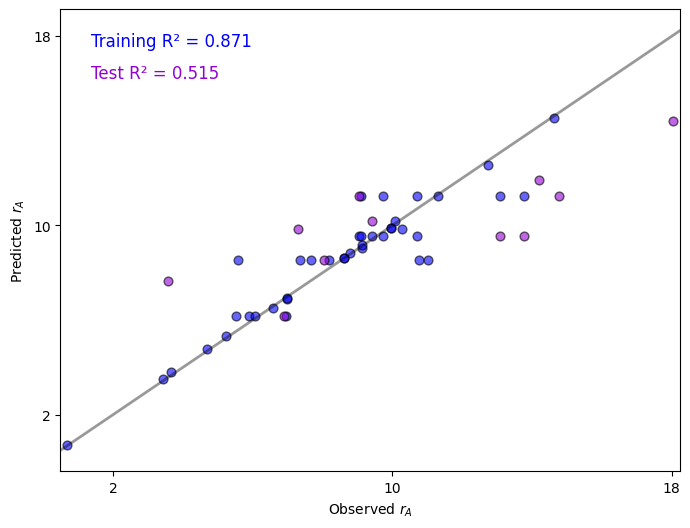

<Figure size 640x480 with 0 Axes>

Data split: 40 training sequences, 11 test sequences
Features per sequence: 534

LASSO RESULTS:
Best regularization strength (alpha): 100.000000
Non-zero coefficients: 0 out of 534 (0.0%)
Training R²: 0.000
Test R²: -0.059


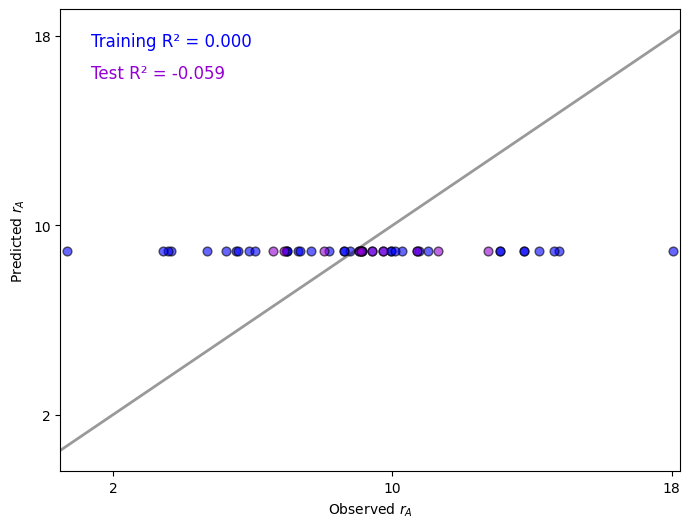

<Figure size 640x480 with 0 Axes>

Data split: 40 training sequences, 11 test sequences
Features per sequence: 534

LASSO RESULTS:
Best regularization strength (alpha): 0.910298
Non-zero coefficients: 8 out of 534 (1.5%)
Training R²: 0.262
Test R²: -0.152


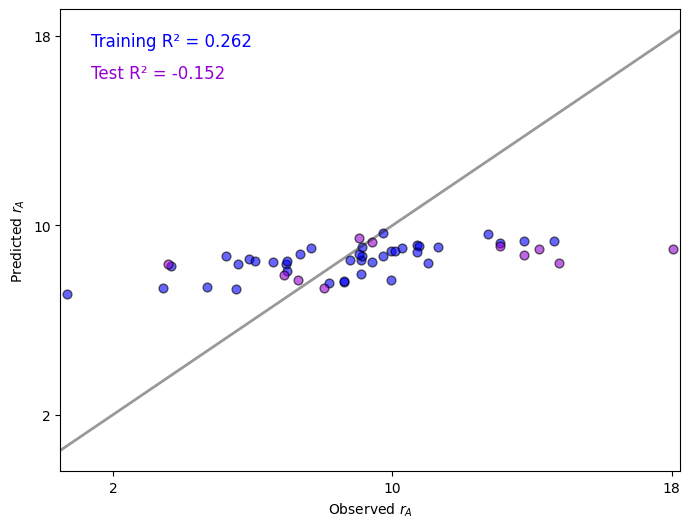

<Figure size 640x480 with 0 Axes>

In [101]:
msa_encoding = hydrophobic_encoding(msa_conserved) 


results = msa_regression(msa_encoding, rates, test_size=0.2, random_state=42)
test_r2 = results['test_r2']
shuffled_rates = rates.copy()
np.random.shuffle(shuffled_rates)
results = msa_regression(msa_encoding, shuffled_rates, test_size=0.2, random_state=42)

msa_encoding_shuffle = msa_encoding.copy()
for row in msa_encoding_shuffle:
    random.shuffle(row)
results = msa_regression(msa_encoding_shuffle, rates, test_size=0.2, random_state=42)

# test_r2_shuffle_rate = np.zeros(100)
# for i in range(100):
#     shuffled_rates = rates.copy()
#     np.random.shuffle(shuffled_rates)
#     results = msa_regression(msa_encoding, shuffled_rates, test_size=0.2, random_state=42, plot = False)
#     test_r2_shuffle_rate[i] = results['test_r2']
    
# test_r2_shuffle_msa = np.zeros(100)
# for i in range(100):
#     msa_encoding_shuffle = msa_encoding.copy()
#     for row in msa_encoding_shuffle:
#         random.shuffle(row)
#     results = msa_regression(msa_encoding_shuffle, rates, test_size=0.2, random_state=42, plot = False)
#     test_r2_shuffle_msa[i] = results['test_r2']
    

    


    
    

In [102]:
# use Soil11.scaffold_431547323_c1_2 as a reference

#find its sequence in the msa

from Bio import AlignIO

def extract_sequence_by_id(msa_file, sequence_id, file_format="fasta"):
    """
    Extract a specific sequence from MSA by sequence ID
    
    Args:
        msa_file: Path to MSA file
        sequence_id: ID of the sequence to extract
        file_format: Format of MSA file (fasta, clustal, stockholm, etc.)
    
    Returns:
        Bio.SeqRecord object or None if not found
    """
    alignment = AlignIO.read(msa_file, file_format)
    
    for record in alignment:
        if sequence_id in record.id:
            return record
    
    print(f"Sequence ID '{sequence_id}' not found in MSA")
    return None

# Usage
msa_path = "../data/isolate_seqs/MSA_TIGR01580_noX_with_soil_seqs_57_isolates.aln-fasta"
target_id = "Soil11.scaffold_431547323_c1_2"
sequence_record = extract_sequence_by_id(msa_path, target_id)

if sequence_record:
    print(f"ID: {sequence_record.id}")
    print(f"Sequence: {sequence_record.seq}")
    print(f"Length: {len(sequence_record.seq)}")
    
from Bio import AlignIO
import numpy as np

def get_ungapped_indices(msa_file, sequence_id, file_format="fasta"):
    """
    Get indices where the specified sequence has no gaps
    """
    # Extract the sequence
    alignment = AlignIO.read(msa_file, file_format)
    target_record = None
    
    for record in alignment:
        if sequence_id in record.id:
            target_record = record
            break
    
    if target_record is None:
        print(f"Sequence '{sequence_id}' not found")
        return None
    
    sequence_str = str(target_record.seq)
    
    # Find indices without gaps
    ungapped_indices = [i for i, char in enumerate(sequence_str) 
                       if char != '-' and char != '.']
    
    return ungapped_indices, sequence_str


ungapped_indices, full_sequence = get_ungapped_indices(msa_path, target_id)

print(f"Ungapped indices: {ungapped_indices[:10]}...")  # First 10 indices
print(f"Total ungapped positions: {len(ungapped_indices)}")
print(f"Sequence length: {len(full_sequence)}")

retained_positions = np.load('../data/isolate_seqs/retained_positions.npy')

ID: Soil11.scaffold_431547323_c1_2
Sequence: -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------MS--ADR-------F-----------------KDEPCRGRC-DWEEFYRNRWQY----------DKVVRSTHGVNCTGSCSWMVHVKDGIVAWELQAKDYPQFD-A-----SIP-------------NYE----P-RGCARGISYSWYLYSPLRVKYPYVR---GALLDRWLEAKES-L-PDPVEAWQSIVE-----------DPQA-RASWTGKRGMGGFR---RASWE

### Try a monte carlo cross validation

### make a new function which automatically shuffles and overlays results. 

In [ ]:
import numpy as np
from sklearn.model_selection import ShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

def msa_regression_resampling(msa, values, test_size=0.2, n_splits=100, 
                      random_state=42, plot=True):
    """
    Lasso regression for MSA with Monte Carlo cross-validation.
    """
    
    print(f"Total sequences: {msa.shape[0]}")
    print(f"Features per sequence: {msa.shape[1]}")
    print(f"Running {n_splits} Monte Carlo splits...")
    
    
    shuffled_values = values.copy()
    np.random.shuffle(shuffled_values)
    
    #results
    train_r2_scores = []
    test_r2_scores = []
    shuff_r2_scores = []
    
    y_train_true = []
    y_train_pred = []
    
    y_test_true = []
    y_test_pred = []
    
    y_true_shuf = []
    y_pred_shuf = []
    
    
    
    #monte carlo cross validation
    mc_cv = ShuffleSplit(n_splits=n_splits, test_size=test_size, 
                         random_state=random_state)
    
    #start a count for percent overlap
    sector_percent = 0
    
    #track nonzero indices
    nonzero_set = []
    coefficient_set = []
    intercept_set = []
    
    
    for split_idx, (train_idx, test_idx) in enumerate(mc_cv.split(msa)):
        #splitting
        X_train, X_test = msa[train_idx], msa[test_idx]
        y_train, y_test = values[train_idx], values[test_idx]
        y_train_shuffle, y_test_shuffle = shuffled_values[train_idx], shuffled_values[test_idx]
        
        #scaling
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        #fitting
        model = LassoCV(
            alphas=np.logspace(-2, 2, 50),
            cv=5,
            max_iter=10000,
            random_state=random_state + split_idx if random_state else None
        )
        
        model_shuffle = LassoCV(
            alphas=np.logspace(-2, 2, 50),
            cv=5,
            max_iter=10000,
            random_state=random_state + split_idx if random_state else None
        )
        
        model.fit(X_train_scaled, y_train)
        model_shuffle.fit(X_train_scaled, y_train_shuffle)
        
        coef = model.coef_  # Coefficients for all features
        nonzero_indices = np.where(coef != 0)[0]  # Indices where coefficient is nonzero
        nonzero_set.extend(nonzero_indices)
        coef_full = np.zeros(N)
        coef_full[conserved_indices] = coef
        coefficient_set.append(coef_full)
        intercept_set.append(model.intercept_)
        if len(nonzero_indices != 0):
            overlap = len(set(nonzero_indices) & set(sector_conserved))/(len(nonzero_indices))
        else:
            overlap = 0
        sector_percent += overlap/n_splits 
        
        #predicting
        y_pred_train = model.predict(X_train_scaled)
        y_pred_test = model.predict(X_test_scaled)
        
        y_pred_test_shuffle = model_shuffle.predict(X_test_scaled)
        
        
        train_r2_scores.append(r2_score(y_train, y_pred_train))
        test_r2_scores.append(r2_score(y_test, y_pred_test))
        
        shuff_r2_scores.append(r2_score(y_test_shuffle, y_pred_test_shuffle))
        
        #storing
        y_test_true.extend(y_test)
        y_test_pred.extend(y_pred_test)
        y_train_true.extend(y_train)
        y_train_pred.extend(y_pred_train)
        
        y_true_shuf.extend(y_test_shuffle)
        y_pred_shuf.extend(y_pred_test_shuffle)
        
        if (split_idx + 1) % 20 == 0:
            print(f"  Completed {split_idx + 1}/{n_splits} splits...")
    

    y_train_true = np.array(y_train_true)
    y_train_pred = np.array(y_train_pred)
    y_test_true = np.array(y_test_true)
    y_test_pred = np.array(y_test_pred)
    
    

    print(f"\nMonte Carlo Results ({n_splits} splits):")
    print(f"Test R²: {np.mean(test_r2_scores):.3f} ± {np.std(test_r2_scores):.3f}")
    print(f"Range: [{np.min(test_r2_scores):.3f}, {np.max(test_r2_scores):.3f}]")
    
    # Simple plot
    if plot:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
        
        # 1. Predicted vs Observed
        ax1.scatter(y_test_true, y_test_pred, alpha=0.2, s=30, 
                   facecolors='darkviolet', edgecolors='black', linewidth=1, label = 'Test')
        ax1.scatter(y_train_true, y_train_pred, alpha=0.2, s=30, 
                   facecolors='blue', edgecolors='black', linewidth=1, label = 'Train')
        # ax1.scatter(y_test_shuffle, y_pred_test_shuffle, alpha = 0.5, s = 30,
        #             facecolors='red', edgecolors='black', linewidth=1)
        ax1.legend()
        
        # Add y=x line
        all_vals = np.concatenate([y_test_true, y_test_pred])
        min_val, max_val = all_vals.min(), all_vals.max()
        ax1.plot([min_val, max_val], [min_val, max_val], 
                'k--', alpha=0.5, linewidth=2)
        
        ax1.set_xlabel('Observed $r_A$', fontname='Helvetica', fontsize='x-large', fontweight='bold')
        ax1.set_ylabel('Predicted $r_A$', fontname='Helvetica', fontsize='x-large', fontweight='bold')
        ax1.set_title(f'Prediction', fontname='Helvetica', fontsize='x-large', fontweight='bold')
        ax1.grid(True, alpha=0.3)
        
        # 2. R² distribution
        ax2.hist(test_r2_scores, bins=50, alpha=0.5, 
                color='darkviolet', edgecolor='black', label = 'Test Scores')
        ax2.hist(shuff_r2_scores, bins = 30, alpha = 0.5,
                 color = 'red', edgecolor = 'black', label = 'Null')
        ax2.axvline(0, color='black', linestyle=':', linewidth=1)
        ax2.set_xlabel('Test R²', fontname='Helvetica', fontsize='x-large', fontweight='bold')
        ax2.set_ylabel('Frequency', fontname='Helvetica', fontsize='x-large', fontweight='bold')
        ax2.set_title('Distribution of Test R² Scores', fontname='Helvetica', fontsize='x-large', fontweight='bold')
        ax2.legend()
        ax2.set_xlim(-1, 1)
        ax2.set_xticks([-1, 0, 1])
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    return {
        'test_r2_mean': np.mean(test_r2_scores),
        'test_r2_std': np.std(test_r2_scores),
        'test_r2_scores': np.array(test_r2_scores),
        'train_r2_scores': np.array(train_r2_scores),
        'n_splits': n_splits,
        'sector_percent': sector_percent,
        'nonzero_set': nonzero_set,
        'coefficient_set': coefficient_set,
        'intercept_set': intercept_set
    }

Total sequences: 51
Features per sequence: 534
Running 100 Monte Carlo splits...


/Users/joelandsittel/Documents/soil/env/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.179e-02, tolerance: 3.943e-02
  model = cd_fast.enet_coordinate_descent(
/Users/joelandsittel/Documents/soil/env/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.145e-02, tolerance: 3.943e-02
  model = cd_fast.enet_coordinate_descent(


  Completed 20/100 splits...


/Users/joelandsittel/Documents/soil/env/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.733e-02, tolerance: 3.055e-02
  model = cd_fast.enet_coordinate_descent(
/Users/joelandsittel/Documents/soil/env/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.043e-02, tolerance: 2.538e-02
  model = cd_fast.enet_coordinate_descent(


  Completed 40/100 splits...


...

  Completed 60/100 splits...


/Users/joelandsittel/Documents/soil/env/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.128e-01, tolerance: 3.281e-02
  model = cd_fast.enet_coordinate_descent(
/Users/joelandsittel/Documents/soil/env/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.581e-02, tolerance: 2.927e-02
  model = cd_fast.enet_coordinate_descent(


  Completed 80/100 splits...


/Users/joelandsittel/Documents/soil/env/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.893e-02, tolerance: 3.317e-02
  model = cd_fast.enet_coordinate_descent(


  Completed 100/100 splits...

Monte Carlo Results (100 splits):
Test R²: -0.064 ± 0.811
Range: [-4.716, 0.815]


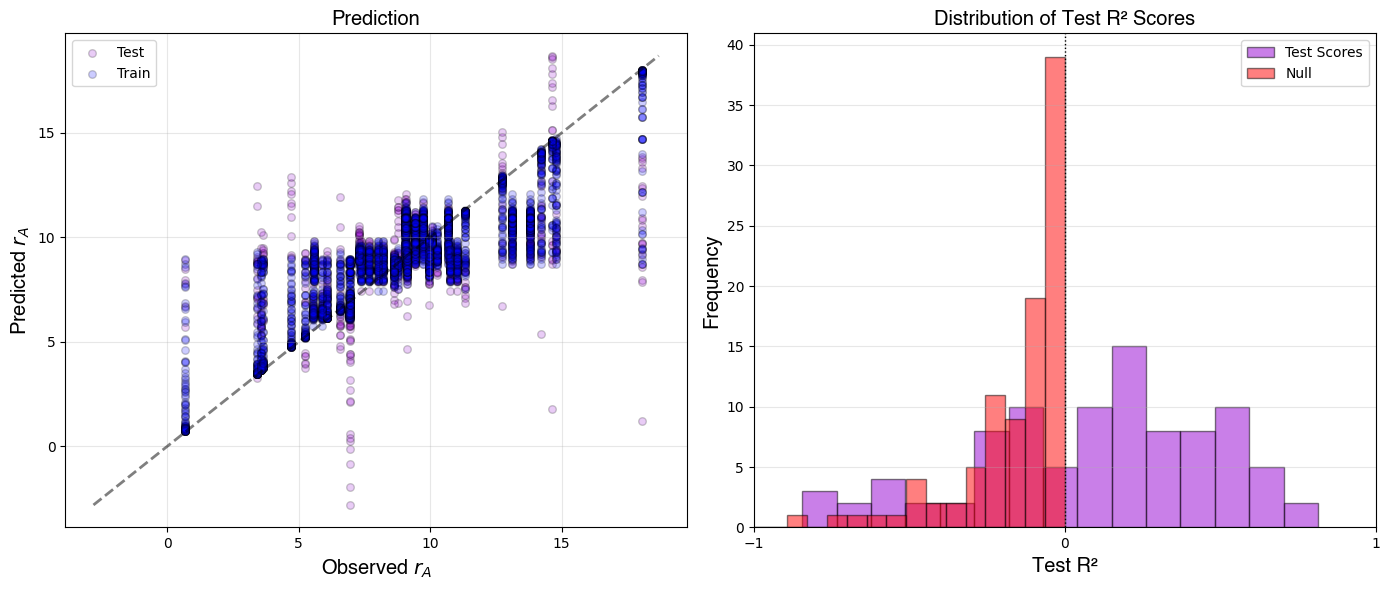

percent nonzero indices in sectors: 0.1191940967552376


In [137]:
results = msa_regression_resampling(msa_encoding, rates, test_size=0.15, random_state=42, n_splits=100)
print('percent nonzero indices in sectors:', results['sector_percent'])

# shuffled_rates = rates.copy()
# np.random.shuffle(shuffled_rates)
# results = msa_regression_complete(msa_encoding, shuffled_rates, test_size=0.15, random_state=42, n_splits=100)

# msa_encoding_shuffle = msa_encoding.copy()
# for row in msa_encoding_shuffle:
#     random.shuffle(row)
# results = msa_regression_complete(msa_encoding_shuffle, rates, test_size=0.15, random_state=42, n_splits=100)


2150


(array([ 24.,   0.,   0.,  29.,  16.,   1.,  21.,   3.,  36.,  23.,  17.,
         16.,  24., 115.,  74.,   0.,  29.,  54., 185.,  16.,  26.,  30.,
          0., 115.,   3.,  76.,  78., 110., 100.,   8.,  21.,  52.,  31.,
        183.,  85.,  96.,   3.,  49.,   8.,   0.,   3.,  96.,  16.,  46.,
          0.,   0.,  69.,   0.,  41., 122.]),
 array([  24.  ,   46.04,   68.08,   90.12,  112.16,  134.2 ,  156.24,
         178.28,  200.32,  222.36,  244.4 ,  266.44,  288.48,  310.52,
         332.56,  354.6 ,  376.64,  398.68,  420.72,  442.76,  464.8 ,
         486.84,  508.88,  530.92,  552.96,  575.  ,  597.04,  619.08,
         641.12,  663.16,  685.2 ,  707.24,  729.28,  751.32,  773.36,
         795.4 ,  817.44,  839.48,  861.52,  883.56,  905.6 ,  927.64,
         949.68,  971.72,  993.76, 1015.8 , 1037.84, 1059.88, 1081.92,
        1103.96, 1126.  ]),
 <BarContainer object of 50 artists>)

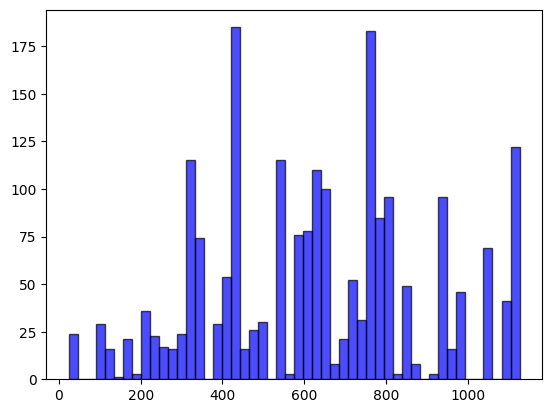

In [105]:
print(len(results['nonzero_set']))
plt.hist(conserved_indices[results['nonzero_set']], bins = 50, color = 'Blue', alpha = 0.7, edgecolor='black') #conserved_indices[results['nonzero_set']] indices selected by lasso out of 1200


[ 0.  0. -0. ...  0.  0.  0.]


<BarContainer object of 1130 artists>

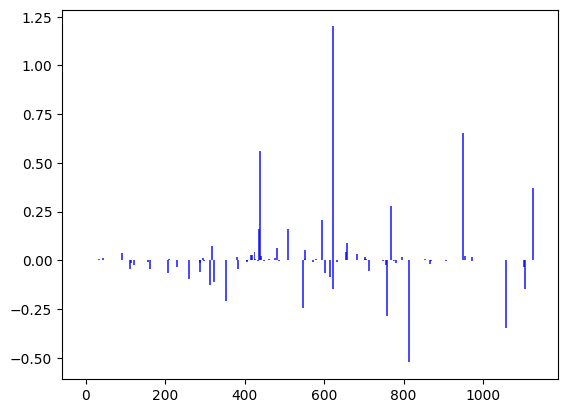

In [106]:
print(results['coefficient_set'][1])
n = len(results['coefficient_set'])
x = np.linspace(0, N-1, N)
result = np.zeros(N)
for i in range(n):
    result += results['coefficient_set'][i]/n
    
plt.bar(x, result, width = 5, alpha = 0.7, color = 'Blue')

<BarContainer object of 1130 artists>

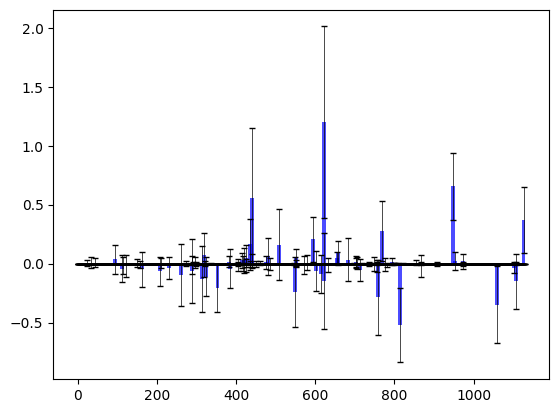

In [107]:
results_mean = np.zeros(N)
results_stdv = np.zeros(N)

for i in range(N):
    results_mean[i] = np.mean(np.array(results['coefficient_set'])[:,i])
    results_stdv[i] = np.std(np.array(results['coefficient_set'])[:,i])
    

plt.bar(x, results_mean, yerr = results_stdv, width = 10,  alpha = 0.7, color = 'Blue', error_kw={'elinewidth': 0.5, 'capsize': 2})

In [108]:
coefficients = np.zeros(N)
for i in range(N):
    if np.abs(results_mean[i]) > results_stdv[i]:
        coefficients[i] = results_mean[i]
        
        
for i in range(N):
    if coefficients[i] != 0:
        print(i, coefficients[i])

353 -0.2088162980969597
594 0.204866463167701
623 1.2000614992140686
769 0.2774939316963709
813 -0.524610186923246
949 0.6544514640965612
1058 -0.34825229544466185
1126 0.3709015808445175


100
[1066 1109 1021 1110 1037 1085 1118 1101 1094 1119 1112 1099  998 1042
 1103 1075 1082 1050 1100 1001 1056 1084 1034 1080 1015 1115 1060 1045
 1088 1093 1010 1039 1035 1108  995 1026 1125 1027 1053 1016  997  993
 1086 1013 1054 1051 1044 1106 1004 1000 1006  994 1011  959 1067  967
  958 1102  948  966 1077  952  951  945  974 1074  949 1041]
8.957374852177873


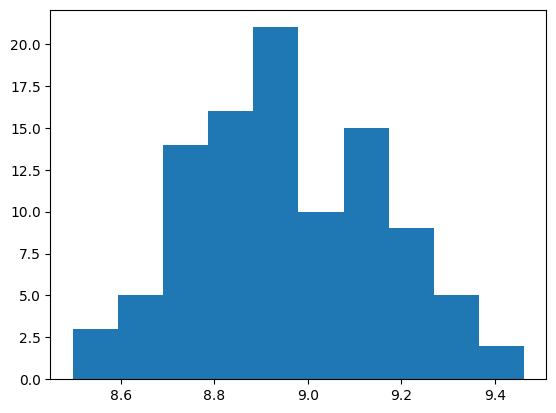

In [109]:
plt.hist(results['intercept_set'])
print(len(results['intercept_set']))
print(sec5_pos)
print(np.mean(results['intercept_set']))



R2:  0.4989649273525312


(0.0, 18.0)

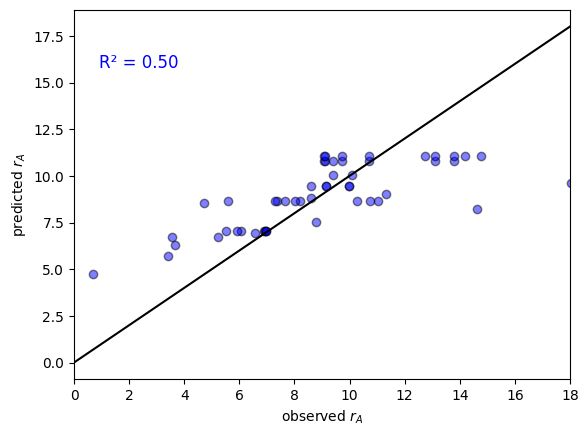

In [151]:
predicted_rates = np.zeros(51)

scaler = StandardScaler()
msa_scaled = scaler.fit_transform(msa_encoding)
    
for i in range(51):
    coded_seq = np.zeros(N)
    coded_seq[conserved_indices] = msa_scaled[i]
    predicted_rates[i] = coded_seq @ coefficients + 9
    
x = np.linspace(0, 18, 10)

r2 = r2_score(rates, predicted_rates)
print('R2: ', r2)

plt.scatter(rates, predicted_rates, color = 'Blue', alpha = 0.5, edgecolors='Black')
plt.xlabel(r'observed $r_A$')
plt.ylabel(r'predicted $r_A$')
plt.text(0.05, 0.88, f'R² = {r2:.2f}', transform=plt.gca().transAxes, 
                color='blue', fontsize=12, verticalalignment='top')
plt.plot(x, x, color = 'black')
plt.xlim(0,18)


###THIS IS MISSING SCALING

In [159]:
msa_proteo_encoding = hydrophobic_encoding(msa_proteo)
msa_proteo_scaled = scaler.fit_transform(msa_proteo_encoding)
proteo_rates = np.zeros(len(msa_proteo))
# for i in range(len(msa_proteo)):
#     seq = msa_proteo_scaled[i]
#     proteo_rates[i] = seq @ coefficients + 9
#     print(orf_list_ordered[i], proteo_rates[i])
    
    
with open('../out/isolates/proteo_rate_predictions_v1.txt', 'w') as f:
    for i in range(len(msa_proteo)):
        seq = msa_proteo_scaled[i]
        proteo_rates[i] = seq @ coefficients + 9
        
        output_line = f"{orf_list_ordered[i]} {proteo_rates[i]:.2f}"
        
        print(output_line)
        
        f.write(output_line + '\n')
    
    

Soil14.scaffold_280216268_c1_12 8.52
Soil6.scaffold_312871021_c1_4 10.12
Soil11.scaffold_587233302_c1_1 9.40
T0.scaffold_786865677_c1_2 8.52
T0.scaffold_172278247_c1_4 8.96
Soil17.scaffold_1202428475_c1_2 8.96
Soil16.scaffold_313969256_c1_10 8.96
Soil12.scaffold_266712765_c1_2 7.89
Soil17.scaffold_332687915_c1_2 7.89
Soil5.scaffold_215117222_c1_59 7.42
Soil3.scaffold_408070428_c1_2 7.34
Soil16.scaffold_804923086_c1_3 8.89
Soil11.scaffold_211583530_c1_6 7.48
Soil6.scaffold_460055642_c1_2 8.89
Soil15.scaffold_16321085_c1_6 8.52
Soil3.scaffold_285743490_c1_2 10.74
Soil5.scaffold_416434691_c1_48 11.74
Soil14.scaffold_576820813_c1_40 11.74


### run regression on full data

In [138]:


def msa_regression_full(msa, values, random_state = 42, plot = True):
    """
    Lasso regression for MSA one-hot encoded data (sets coefficients to zero)
    """

    
    X = msa
    Y = values
    

    model = LassoCV(
        alphas=np.logspace(-2, 2, 50),  
        cv=2,  # 5-fold cross-validation
        max_iter=10000,  
        random_state=random_state
    )
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    model.fit(X_scaled, Y)
    
    Y_pred = model.predict(X_scaled)
    
    #metrics
    r2 = r2_score(Y, Y_pred)
    
    #non-zero coefficients (feature selection)
    n_nonzero = np.sum(model.coef_ != 0)
    # print('model coefficients', model.coef_)
    # Print results
    
    
    
    if plot: 
        print(f"\nLASSO RESULTS:")
        print(f"Best regularization strength (alpha): {model.alpha_:.6f}")
        print(f"Non-zero coefficients: {n_nonzero} out of {len(model.coef_)} ({n_nonzero/len(model.coef_)*100:.1f}%)")
        print(f"R²: {r2:.3f}")
    
        plt.figure(figsize=(8, 6))


        plt.scatter(Y, Y_pred, alpha=0.6, label='Training data', s = 40, facecolors='blue', edgecolors='black',  linewidth=1)

        all_obs = Y
        plt.plot([all_obs.min() - 0.2, all_obs.max() + 0.2], [all_obs.min() - 0.2, all_obs.max() + 0.2], lw=2, color = 'Black', alpha = 0.4)
        plt.xlim(all_obs.min()- 0.2 , all_obs.max()+ 0.2)
        plt.xlabel('Observed $r_A$')
        plt.ylabel('Predicted $r_A$')
        # plt.legend()
        plt.xticks([2, 10, 18])
        plt.yticks([2, 10, 18])
        
        plt.text(0.05, 0.88, f'R² = {r2:.3f}', transform=plt.gca().transAxes, 
                color='blue', fontsize=12, verticalalignment='top')

        plt.show()
    
        plt.tight_layout()
        plt.show()
    
    return {
        'model': model,
        'y_pred': Y_pred,
        'r2': r2,
        'n_nonzero_coef': n_nonzero,
        'total_features': len(model.coef_),
        'coefficients': model.coef_,
        'intercept': model.intercept_
    }


LASSO RESULTS:
Best regularization strength (alpha): 0.244205
Non-zero coefficients: 20 out of 534 (3.7%)
R²: 0.774


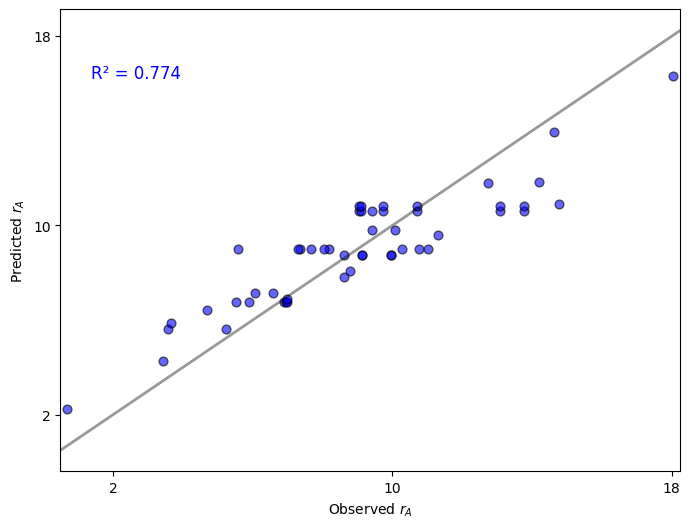

<Figure size 640x480 with 0 Axes>

Soil14.scaffold_280216268_c1_12 8.29
Soil6.scaffold_312871021_c1_4 9.84
Soil11.scaffold_587233302_c1_1 9.01
T0.scaffold_786865677_c1_2 10.29
T0.scaffold_172278247_c1_4 9.13
Soil17.scaffold_1202428475_c1_2 9.13
Soil16.scaffold_313969256_c1_10 9.10
Soil12.scaffold_266712765_c1_2 7.07
Soil17.scaffold_332687915_c1_2 7.44
Soil5.scaffold_215117222_c1_59 7.35
Soil3.scaffold_408070428_c1_2 7.96
Soil16.scaffold_804923086_c1_3 8.96
Soil11.scaffold_211583530_c1_6 6.56
Soil6.scaffold_460055642_c1_2 9.02
Soil15.scaffold_16321085_c1_6 10.18
Soil3.scaffold_285743490_c1_2 8.93
Soil5.scaffold_416434691_c1_48 10.90
Soil14.scaffold_576820813_c1_40 12.81


In [160]:
results = msa_regression_full(msa_encoding, rates)
coefficients = np.zeros(N)
coefficients[conserved_indices] = results['coefficients']
intercept = results['intercept']

with open('../out/isolates/proteo_rate_predictions_v2.txt', 'w') as f:
    for i in range(len(msa_proteo)):
        seq = msa_proteo_scaled[i]
        proteo_rates[i] = seq @ coefficients + intercept
        
        output_line = f"{orf_list_ordered[i]} {proteo_rates[i]:.2f}"
        
        print(output_line)
        
        f.write(output_line + '\n')


In [ ]:
print(msa_encoding.shape)
print(rates.shape)



(51, 534)
(51,)
